<a href="https://colab.research.google.com/github/GabrielAlcant/Matematica-Computacional/blob/main/Atividade_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2.2 — Linear Regression, p-value e Métricas


## A — Correlação

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

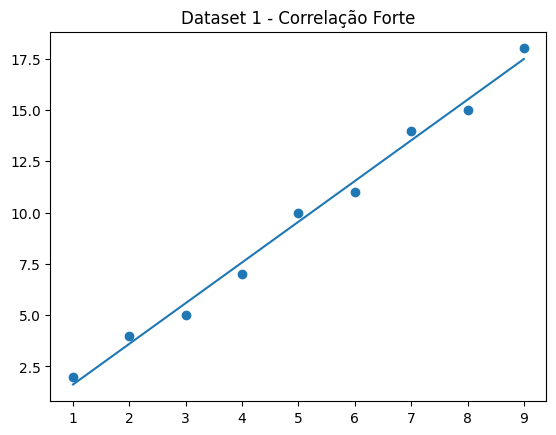

p-value: 2.2303698716250834e-08
Covariância: 14.875


In [4]:
# Dataset 1
x1 = np.array([1,2,3,4,5,6,7,8,9])
y1 = np.array([2,4,5,7,10,11,14,15,18])

res1 = linregress(x1, y1)
y1_reg = res1.slope * x1 + res1.intercept

plt.scatter(x1, y1)
plt.plot(x1, y1_reg)
plt.title("Dataset 1 - Correlação Forte")
plt.show()

print("p-value:", res1.pvalue)
print("Covariância:", np.cov(x1, y1)[0,1])

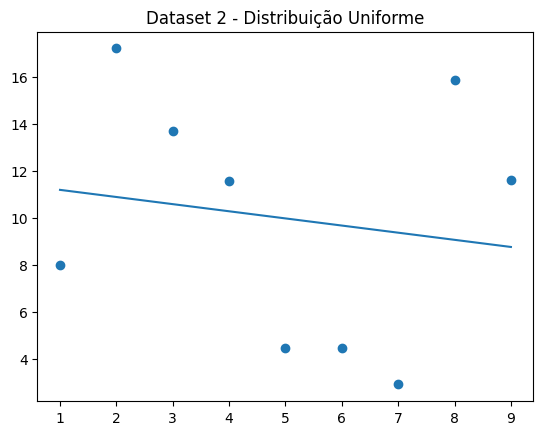

p-value: 0.6837613150481096
Covariância: -2.2755990669376054


In [5]:
# Dataset 2
np.random.seed(42)
x2 = np.linspace(1,9,9)
y2 = np.random.uniform(min(y1), max(y1), 9)

res2 = linregress(x2, y2)
y2_reg = res2.slope * x2 + res2.intercept

plt.scatter(x2, y2)
plt.plot(x2, y2_reg)
plt.title("Dataset 2 - Distribuição Uniforme")
plt.show()

print("p-value:", res2.pvalue)
print("Covariância:", np.cov(x2, y2)[0,1])

## B — Intervalo de Confiança

In [6]:
from scipy import stats

dados = np.array([70,75,80,85,90,78,82,88,76,84])
media = np.mean(dados)
desvio = np.std(dados, ddof=1)
n = len(dados)

for cl in [0.90, 0.95, 0.99]:
    ic = stats.t.interval(cl, n-1, media, desvio/np.sqrt(n))
    print(f"IC {int(cl*100)}%:", ic)

IC 90%: (np.float64(77.19746797208403), np.float64(84.40253202791597))
IC 95%: (np.float64(76.35428719846293), np.float64(85.24571280153707))
IC 99%: (np.float64(74.4132485808732), np.float64(87.1867514191268))


## C — Teste de Hipótese (p-value)

In [7]:
controle = np.array([50,52,49,51,50,48,52])
teste = np.array([55,56,54,57,58,55,56])

t_stat, p_value = stats.ttest_ind(controle, teste)
print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rejeita H0")
else:
    print("Não rejeita H0")

t-statistic: -7.326824205696247
p-value: 9.137003681733123e-06
Rejeita H0


# E — Reproduzindo Confidence Intervals em Código

Este notebook reproduz em Python o conteúdo dos slides 24 a 46 do material *What are Confidence Intervals?*, utilizando simulações e visualizações para demonstrar os conceitos.

## 1. Geração de uma amostra e Intervalo de Confiança

In [8]:

import numpy as np
from scipy import stats

np.random.seed(42)

true_mean = 100
true_std = 15

sample = np.random.normal(true_mean, true_std, 30)

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

ic_95 = stats.t.interval(
    0.95,
    df=len(sample)-1,
    loc=sample_mean,
    scale=sample_std / np.sqrt(len(sample))
)

sample_mean, ic_95


(np.float64(97.17779656223442),
 (np.float64(92.13677771552751), np.float64(102.21881540894132)))

O intervalo de confiança é calculado a partir da média e do desvio padrão amostrais. O parâmetro verdadeiro é fixo, mas o intervalo muda a cada nova amostra.

## 2. Interpretação do Intervalo de Confiança

In [9]:

print(f"Média verdadeira: {true_mean}")
print(f"Média amostral: {sample_mean:.2f}")
print(f"IC 95%: {ic_95}")


Média verdadeira: 100
Média amostral: 97.18
IC 95%: (np.float64(92.13677771552751), np.float64(102.21881540894132))


A interpretação correta é que, ao repetir o experimento muitas vezes, 95% dos intervalos construídos conterão a média verdadeira.

## 3. Simulação de Vários Intervalos de Confiança

In [10]:

import matplotlib.pyplot as plt

num_samples = 100
sample_size = 30
intervals = []

for _ in range(num_samples):
    sample = np.random.normal(true_mean, true_std, sample_size)
    mean = np.mean(sample)
    std = np.std(sample, ddof=1)

    ic = stats.t.interval(
        0.95,
        df=sample_size-1,
        loc=mean,
        scale=std / np.sqrt(sample_size)
    )
    intervals.append(ic)


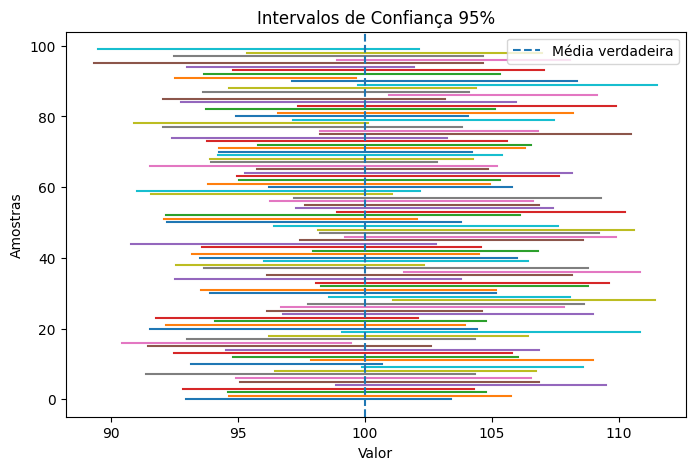

In [11]:

plt.figure(figsize=(8,5))

for i, (low, high) in enumerate(intervals):
    plt.plot([low, high], [i, i])

plt.axvline(true_mean, linestyle='--', label='Média verdadeira')
plt.xlabel("Valor")
plt.ylabel("Amostras")
plt.title("Intervalos de Confiança 95%")
plt.legend()
plt.show()


A maioria dos intervalos contém a média verdadeira, mas alguns não, o que é esperado dado o nível de confiança.

## 4. Comparação entre Níveis de Confiança

In [12]:

confidence_levels = [0.90, 0.95, 0.99]

for cl in confidence_levels:
    ic = stats.t.interval(
        cl,
        df=len(sample)-1,
        loc=sample_mean,
        scale=sample_std / np.sqrt(len(sample))
    )
    print(f"IC {int(cl*100)}%: {ic}")


IC 90%: (np.float64(92.98984075167186), np.float64(101.36575237279698))
IC 95%: (np.float64(92.13677771552751), np.float64(102.21881540894132))
IC 99%: (np.float64(90.38394172903821), np.float64(103.97165139543063))


Quanto maior o nível de confiança, mais largo é o intervalo, representando maior incerteza.

## 5. Relação com Testes de Hipótese

In [13]:

hypothetical_mean = 105

if ic_95[0] <= hypothetical_mean <= ic_95[1]:
    print("Valor plausível segundo o IC 95%")
else:
    print("Valor não plausível segundo o IC 95%")


Valor não plausível segundo o IC 95%


Se um valor não pertence ao intervalo de confiança, ele seria rejeitado em um teste de hipótese com o mesmo nível de significância.

In [14]:
print("Média verdadeira:", true_mean)
print("Média amostral:", sample_mean)
print("IC 95%:", ic_95)

Média verdadeira: 100
Média amostral: 97.17779656223442
IC 95%: (np.float64(92.13677771552751), np.float64(102.21881540894132))



## Questão F — Regressão Linear, Variação do Intercepto e R²

Aplicamos regressão linear para analisar como o intercepto **a** influencia o ajuste da reta.

Modelo:
y = a + b·x

Etapas:
1. Ajustar a melhor reta com **scikit-learn**
2. Obter estatísticas com **statsmodels**
3. Fixar o coeficiente angular **b**
4. Variar diferentes valores de **a**
5. Comparar os valores de **R²**


In [15]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

x = np.array([1,2,3,4,5,6,7,8,9]).reshape(-1,1)
y = np.array([2,4,5,4,5,7,8,9,10])

model = LinearRegression()
model.fit(x,y)

a_sklearn = model.intercept_
b_sklearn = model.coef_[0]
y_pred = model.predict(x)
r2_best = r2_score(y,y_pred)

print("Intercepto ótimo (a):", a_sklearn)
print("Inclinação ótima (b):", b_sklearn)
print("Melhor R²:", r2_best)

x_sm = sm.add_constant(x)
model_sm = sm.OLS(y,x_sm).fit()
print(model_sm.summary())


Intercepto ótimo (a): 1.3333333333333321
Inclinação ótima (b): 0.9333333333333336
Melhor R²: 0.9333333333333333
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     98.00
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.29e-05
Time:                        02:28:43   Log-Likelihood:                -8.8108
No. Observations:                   9   AIC:                             21.62
Df Residuals:                       7   BIC:                             22.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------

a=-2.67 -> R²=-1.6381
a=-0.67 -> R²=0.2905
a=1.33 -> R²=0.9333
a=3.33 -> R²=0.2905
a=5.33 -> R²=-1.6381
a=7.33 -> R²=-4.8524


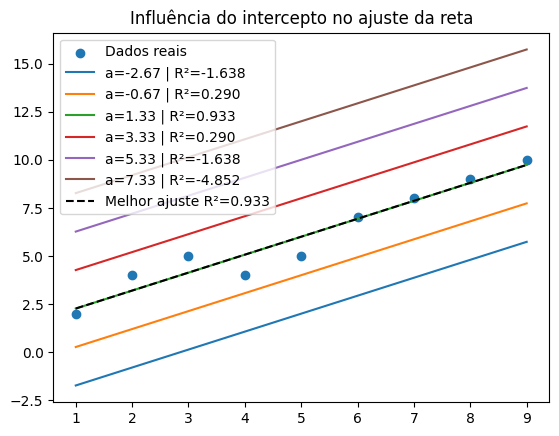

In [16]:

a_values = [a_sklearn-4, a_sklearn-2, a_sklearn, a_sklearn+2, a_sklearn+4, a_sklearn+6]

plt.scatter(x,y,label="Dados reais")

for a in a_values:
    y_var = a + b_sklearn*x.flatten()
    r2 = r2_score(y,y_var)
    print(f"a={a:.2f} -> R²={r2:.4f}")
    plt.plot(x,y_var,label=f"a={a:.2f} | R²={r2:.3f}")

plt.plot(x,y_pred,'k--',label=f"Melhor ajuste R²={r2_best:.3f}")
plt.legend()
plt.title("Influência do intercepto no ajuste da reta")
plt.show()



## Questão G — Fatoração LU com Pivoteamento Parcial

A decomposição LU escreve a matriz A como:

A = P·L·U

Onde:
- **P** é a matriz de permutação (trocas de linha)
- **L** é triangular inferior
- **U** é triangular superior

O pivoteamento parcial melhora a estabilidade numérica escolhendo o maior pivô em valor absoluto.


In [17]:

import numpy as np

def lu_pivoteamento(A, b):
    A = A.astype(float)
    n = len(A)
    P = np.eye(n)
    L = np.eye(n)
    U = A.copy()

    print("Matriz inicial A:\n", A, "\n")

    for k in range(n-1):
        pivot = np.argmax(abs(U[k:, k])) + k
        if pivot != k:
            U[[k, pivot]] = U[[pivot, k]]
            P[[k, pivot]] = P[[pivot, k]]
            if k > 0:
                L[[k, pivot], :k] = L[[pivot, k], :k]
            print(f"Troca de linhas {k} ↔ {pivot}")
            print("U após troca:\n", U, "\n")

        for i in range(k+1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i] = U[i] - L[i, k] * U[k]
            print(f"m({i},{k}) = {L[i,k]:.4f}")
            print("U:\n", U, "\n")

    print("Matriz L:\n", L)
    print("Matriz U:\n", U)
    print("Matriz P:\n", P)

    Pb = P @ b
    y = np.zeros(n)
    for i in range(n):
        y[i] = Pb[i] - np.dot(L[i,:i], y[:i])

    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - np.dot(U[i,i+1:], x[i+1:])) / U[i,i]

    print("\nSolução final x =", x)
    return x

A = np.array([[3,-4,1],[1,2,2],[4,0,-3]])
b = np.array([9,3,-2])
lu_pivoteamento(A,b)


Matriz inicial A:
 [[ 3. -4.  1.]
 [ 1.  2.  2.]
 [ 4.  0. -3.]] 

Troca de linhas 0 ↔ 2
U após troca:
 [[ 4.  0. -3.]
 [ 1.  2.  2.]
 [ 3. -4.  1.]] 

m(1,0) = 0.2500
U:
 [[ 4.    0.   -3.  ]
 [ 0.    2.    2.75]
 [ 3.   -4.    1.  ]] 

m(2,0) = 0.7500
U:
 [[ 4.    0.   -3.  ]
 [ 0.    2.    2.75]
 [ 0.   -4.    3.25]] 

Troca de linhas 1 ↔ 2
U após troca:
 [[ 4.    0.   -3.  ]
 [ 0.   -4.    3.25]
 [ 0.    2.    2.75]] 

m(2,1) = -0.5000
U:
 [[ 4.     0.    -3.   ]
 [ 0.    -4.     3.25 ]
 [ 0.     0.     4.375]] 

Matriz L:
 [[ 1.    0.    0.  ]
 [ 0.75  1.    0.  ]
 [ 0.25 -0.5   1.  ]]
Matriz U:
 [[ 4.     0.    -3.   ]
 [ 0.    -4.     3.25 ]
 [ 0.     0.     4.375]]
Matriz P:
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]

Solução final x = [ 1. -1.  2.]


array([ 1., -1.,  2.])


## Questão H — Método de Gauss-Jacobi

O método de Jacobi é iterativo. Cada nova aproximação usa apenas valores da iteração anterior.

Fórmula geral:
xᵢ^(k+1) = (bᵢ − Σ aᵢⱼ xⱼ^(k)) / aᵢᵢ


In [18]:

def gauss_jacobi(A, b, x0, tol=1e-4, max_iter=20):
    n = len(b)
    x = x0.copy()
    print("Iteração 0:", x)

    for k in range(1, max_iter+1):
        x_new = np.zeros(n)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        print(f"Iteração {k}: {x_new}")

        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            print("\nConvergiu!")
            return x_new
        x = x_new

    return x

A = np.array([[10,2,1],[1,5,1],[2,3,10]], dtype=float)
b = np.array([7,-8,6], dtype=float)
x0 = np.zeros(3)

gauss_jacobi(A,b,x0)


Iteração 0: [0. 0. 0.]
Iteração 1: [ 0.7 -1.6  0.6]
Iteração 2: [ 0.96 -1.86  0.94]
Iteração 3: [ 0.978 -1.98   0.966]
Iteração 4: [ 0.9994 -1.9888  0.9984]
Iteração 5: [ 0.99792 -1.99956  0.99676]
Iteração 6: [ 1.000236 -1.998936  1.000284]
Iteração 7: [ 0.9997588 -2.000104   0.9996336]
Iteração 8: [ 1.00005744 -1.99987848  1.00007944]
Iteração 9: [ 0.99996775 -2.00002738  0.99995206]
Iteração 10: [ 1.00001027 -1.99998396  1.00001466]

Convergiu!


array([ 1.00001027, -1.99998396,  1.00001466])


## Questão I — Gauss-Seidel e Critério de Sassenfeld

O método de Gauss-Seidel usa valores atualizados imediatamente na mesma iteração.

Critério de Sassenfeld verifica convergência antes de iterar.
Se max(βᵢ) < 1 → Converge.


In [19]:

def sassenfeld(A):
    n = len(A)
    beta = np.zeros(n)

    for i in range(n):
        s = 0
        for j in range(n):
            if j != i:
                if j < i:
                    s += abs(A[i][j]) * beta[j]
                else:
                    s += abs(A[i][j])
        beta[i] = s / abs(A[i][i])

    print("Betas de Sassenfeld:", beta)
    print("Máximo beta =", max(beta))
    if max(beta) < 1:
        print("Método converge!\n")
    else:
        print("Método pode não convergir.\n")


def gauss_seidel(A, b, x0, tol=1e-4, max_iter=20):
    n = len(b)
    x = x0.copy()
    print("Iteração 0:", x)

    for k in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i+1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]

        print(f"Iteração {k}: {x}")

        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            print("\nConvergiu!")
            return x

    return x

A = np.array([[5,1,1],[3,4,1],[3,3,6]], dtype=float)
b = np.array([5,6,0], dtype=float)
x0 = np.zeros(3)

sassenfeld(A)
gauss_seidel(A,b,x0)


Betas de Sassenfeld: [0.4   0.55  0.475]
Máximo beta = 0.55
Método converge!

Iteração 0: [0. 0. 0.]
Iteração 1: [ 1.     0.75  -0.875]
Iteração 2: [ 1.025   0.95   -0.9875]
Iteração 3: [ 1.0075    0.99125  -0.999375]
Iteração 4: [ 1.001625  0.998625 -1.000125]
Iteração 5: [ 1.0003      0.99980625 -1.00005312]
Iteração 6: [ 1.00004938  0.99997625 -1.00001281]
Iteração 7: [ 1.00000731  0.99999772 -1.00000252]

Convergiu!


array([ 1.00000731,  0.99999772, -1.00000252])